# SCAGE Cliff Attention 視覺化

此 notebook 僅用於 cliff finetune 模型 attention 抽取與視覺化：

1. graph token -> atom token attention，作圖前做 min-max normalization
2. 2D 分子圖（紅色強度 + 0-1 colorbar）

> 請在 Docker `scage` container（路徑 `/workspace/`）內執行。


In [1]:
# --- Notebook 啟動位置修正 ---
# 目的：避免在 Notebook/ 目錄執行時，無法 import 專案模組
import os
import sys
from pathlib import Path


def _resolve_project_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    for c in candidates:
        if (c / '_config.py').exists() and (c / 'models').exists() and (c / 'data_process').exists():
            return c.resolve()
    raise RuntimeError('Cannot locate project root. Please open notebook under SCAGE project.')


PROJECT_ROOT = _resolve_project_root()
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'[Init] PROJECT_ROOT = {PROJECT_ROOT}')
print(f'[Init] CWD switched to = {Path.cwd()}')

[Init] PROJECT_ROOT = /workspace
[Init] CWD switched to = /workspace


In [2]:
import os
from pathlib import Path
from copy import deepcopy
from typing import Dict, List

import numpy as np
import torch
import yaml
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D

from _config import pdir, get_downstream_task_names
from data_process.compound_tools import CompoundKit, mol_to_data_pkl
from data_process.data_collator import collator_finetune_pkl
from data_process.function_group_constant import nfg
from models.scage import Scage
from models.layers.encoder import MultiScaleAttention
from utils.global_var_util import GlobalVar
from utils.userconfig_util import config_current_user, config_dataset_form

plt.rcParams['figure.dpi'] = 140
torch.set_printoptions(sci_mode=False, precision=4)
np.set_printoptions(precision=4, suppress=True)

print('cwd:', os.getcwd())

cwd: /workspace


In [3]:
def plot_raw_multiscale_attn_list(attn_per_layer: List[List[torch.Tensor]], title_prefix: str = 'Raw MultiScaleAttention attn_list', batch_idx: int = 0, max_cols: int = 4):
    """Plot full token-token raw attention heatmaps after integrating heads/scales per layer and all layers."""
    if len(attn_per_layer) == 0:
        raise RuntimeError('No attention captured. Check hook registration.')

    layer_mats = []
    for layer_idx, layer_data in enumerate(attn_per_layer):
        scale_mats = []
        raw_shapes = []
        for scale_idx, attn in enumerate(layer_data):
            raw = attn.detach().cpu()
            if raw.ndim != 4:
                raise ValueError(f'Expected attn tensor [batch, heads, tokens, tokens], got shape={tuple(raw.shape)}')
            if batch_idx < 0 or batch_idx >= raw.shape[0]:
                raise ValueError(f'batch_idx out of range: {batch_idx}, batch_size={raw.shape[0]}')

            # Integrate heads only by averaging; keep the original attention values otherwise.
            scale_mats.append(raw[batch_idx].mean(dim=0).numpy())
            raw_shapes.append(tuple(raw.shape))

        layer_mat = np.mean(scale_mats, axis=0)  # integrate multiscale branches into one matrix per layer
        layer_mats.append(layer_mat)
        print(
            f'raw attn layer={layer_idx}, shapes={raw_shapes}, '
            f'head/scale-integrated min={layer_mat.min():.6g}, max={layer_mat.max():.6g}'
        )

    integrated_mat = np.mean(layer_mats, axis=0)
    plot_mats = layer_mats + [integrated_mat]
    plot_titles = [f'Layer {idx}' for idx in range(len(layer_mats))] + ['All layers integrated']

    n_plots = len(plot_mats)
    n_cols = min(max_cols, n_plots)
    n_rows = int(np.ceil(n_plots / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.6 * n_rows), squeeze=False)

    for plot_idx, ax in enumerate(axes.flat):
        if plot_idx >= n_plots:
            ax.axis('off')
            continue
        mat = plot_mats[plot_idx]
        sns.heatmap(
            mat,
            cmap='Blues',
            square=True,
            ax=ax,
            cbar=True,
            xticklabels=True,
            yticklabels=True,
        )
        ax.set_title(f'{plot_titles[plot_idx]} | min={mat.min():.4g}, max={mat.max():.4g}')
        ax.set_xlabel('Key token index')
        ax.set_ylabel('Query token index')

    fig.suptitle(f'{title_prefix} | raw head/scale-integrated full attention matrices', y=1.02)
    fig.tight_layout()
    plt.show()
    print(
        f'raw attn all layers integrated, shape={integrated_mat.shape}, '
        f'min={integrated_mat.min():.6g}, max={integrated_mat.max():.6g}'
    )
    return [fig]

In [4]:
def build_single_batch(smiles: str, device: str = 'cuda') -> Dict[str, torch.Tensor]:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f'Invalid SMILES: {smiles}')
    data = mol_to_data_pkl(mol)
    data['smiles'] = smiles
    data['label'] = np.array([0.0], dtype=np.float32)  # collator 需要 label
    batch = collator_finetune_pkl([data])
    batch = {k: v.to(device) for k, v in batch.items() if v is not None and not isinstance(v, list)}
    batch['edge_weight'] = None
    return batch
def register_attention_hooks(model: torch.nn.Module, sink: List[List[torch.Tensor]]):
    hooks = []
    def _hook(_, __, out):
        # MultiScaleAttention.forward -> (x, attn_list)
        attn_list = out[1]
        sink.append([a.detach().cpu() for a in attn_list])
    for m in model.modules():
        if isinstance(m, MultiScaleAttention):
            hooks.append(m.register_forward_hook(_hook))
    return hooks
def _minmax_normalize_scores(score: np.ndarray, axis: int = -1) -> np.ndarray:
    """Scale attention scores to 0-1 before heatmap/molecule coloring."""
    score = np.asarray(score, dtype=float)
    score_min = score.min(axis=axis, keepdims=True)
    score_max = score.max(axis=axis, keepdims=True)
    return (score - score_min) / (score_max - score_min + 1e-12)


def aggregate_attention(attn_per_layer: List[List[torch.Tensor]], n_atoms: int, layer_idx: int = None):
    if len(attn_per_layer) == 0:
        raise RuntimeError('No attention captured. Check hook registration.')

    # Paper-style: graph token (token 0) -> atom tokens (token 1~N).
    # Per layer: average heads first, then average multiscale branches.
    layer_scores = []
    for layer_data in attn_per_layer:
        scale_scores = []
        for dist_attn in layer_data:
            # shape: [batch, heads, tokens, tokens] -> [batch, atoms]
            score = dist_attn[:, :, 0, 1:n_atoms + 1].mean(dim=1)
            scale_scores.append(score)
        layer_scores.append(torch.stack(scale_scores, dim=0).mean(dim=0))

    # layer_idx=None: all-layer aggregated score; otherwise selected single layer.
    if layer_idx is None:
        selected_score = torch.stack(layer_scores, dim=0).mean(dim=0)
    else:
        if layer_idx < 0 or layer_idx >= len(layer_scores):
            raise ValueError(f'layer_idx out of range: {layer_idx}, total layers={len(layer_scores)}')
        selected_score = layer_scores[layer_idx]

    selected_score_np = selected_score.numpy()
    atom_score_raw = selected_score_np[0]
    atom_score = _minmax_normalize_scores(selected_score_np)[0]
    per_layer_scores = [_minmax_normalize_scores(score.numpy())[0] for score in layer_scores]

    # 1D atom score 用單列 heatmap 顯示，避免回到 atom-atom [N,N] matrix。
    atom_heatmap = atom_score.reshape(1, -1)
    layer_heatmaps = [score.reshape(1, -1) for score in per_layer_scores]
    return atom_heatmap, atom_score_raw, atom_score, layer_heatmaps


def compute_bond_scores(smiles: str, atom_scores: np.ndarray):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f'Invalid SMILES: {smiles}')
    atom_scores = np.asarray(atom_scores, dtype=float)
    bond_scores = []
    bond_indices = []
    for bond in mol.GetBonds():
        a1 = bond.GetBeginAtomIdx()
        a2 = bond.GetEndAtomIdx()
        bond_indices.append((a1, a2))
        bond_scores.append((atom_scores[a1] + atom_scores[a2]) / 2.0)
    return np.asarray(bond_scores, dtype=float).reshape(1, -1), bond_indices


In [5]:
def draw_attention_on_molecule(smiles: str, atom_scores: np.ndarray, size=(700, 420)):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f'Invalid SMILES: {smiles}')
    Chem.rdDepictor.Compute2DCoords(mol)
    n_atoms = mol.GetNumAtoms()
    if len(atom_scores) != n_atoms:
        raise ValueError(f'atom_scores length {len(atom_scores)} != num_atoms {n_atoms}')
    # atom_scores 已在 attention aggregation 階段依 min-max normalization 到 0~1。
    atom_scores = np.clip(np.asarray(atom_scores, dtype=float), 0.0, 1.0)
    # Atom 顏色：紅色 alpha = atom score
    highlight_atoms = list(range(n_atoms))
    atom_cols = {
        i: (1.0, 0.0, 0.0, float(atom_scores[i]))
        for i in highlight_atoms
    }
    # Bond 顏色：edge score = 兩端 atom score 平均
    highlight_bonds = []
    bond_cols = {}
    for bond in mol.GetBonds():
        b_idx = bond.GetIdx()
        a1 = bond.GetBeginAtomIdx()
        a2 = bond.GetEndAtomIdx()
        edge_score = float((atom_scores[a1] + atom_scores[a2]) / 2.0)
        highlight_bonds.append(b_idx)
        bond_cols[b_idx] = (1.0, 0.0, 0.0, edge_score)
    drawer = rdMolDraw2D.MolDraw2DCairo(size[0], size[1])
    opts = drawer.drawOptions()
    opts.useBWAtomPalette()  # 原子元素顏色統一黑色（如 C/H/O）
    opts.addAtomIndices = False
    opts.bondLineWidth = 2
    opts.highlightRadius = 0.42
    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer,
        mol,
        highlightAtoms=highlight_atoms,
        highlightAtomColors=atom_cols,
        highlightBonds=highlight_bonds,
        highlightBondColors=bond_cols,
    )
    drawer.FinishDrawing()
    return drawer.GetDrawingText()


## 第一章：Graph Token -> Atom Attention（新版邏輯）

此章節用來重現你指定的 cliff 分子，並使用新版 graph token 對 atom token 的 attention 作為 atom score：

- `Cc1cc2c(s1)Nc1ccccc1N=C2N1CCN(C)CC1`

流程會：

1. 載入 `cliff` finetune checkpoint
2. 擷取 attention（softmax 後）
3. 取 graph token 對 atom token 的 attention，並在作圖前做 min-max normalization
4. 輸出 0-1 固定色階的 atom heatmap
5. 輸出結構圖（紅色強度 + 0-1 colorbar）

restored dist_bar from checkpoint: [40, 70]
raw attn layer=0, shapes=[(1, 16, 24, 24), (1, 16, 24, 24)], head/scale-integrated min=0, max=0.192115
raw attn layer=1, shapes=[(1, 16, 24, 24), (1, 16, 24, 24)], head/scale-integrated min=0, max=0.26555
raw attn layer=2, shapes=[(1, 16, 24, 24), (1, 16, 24, 24)], head/scale-integrated min=0, max=0.346526
raw attn layer=3, shapes=[(1, 16, 24, 24), (1, 16, 24, 24)], head/scale-integrated min=0, max=0.297354
raw attn layer=4, shapes=[(1, 16, 24, 24), (1, 16, 24, 24)], head/scale-integrated min=0, max=0.412952
raw attn layer=5, shapes=[(1, 16, 24, 24), (1, 16, 24, 24)], head/scale-integrated min=0, max=0.32539


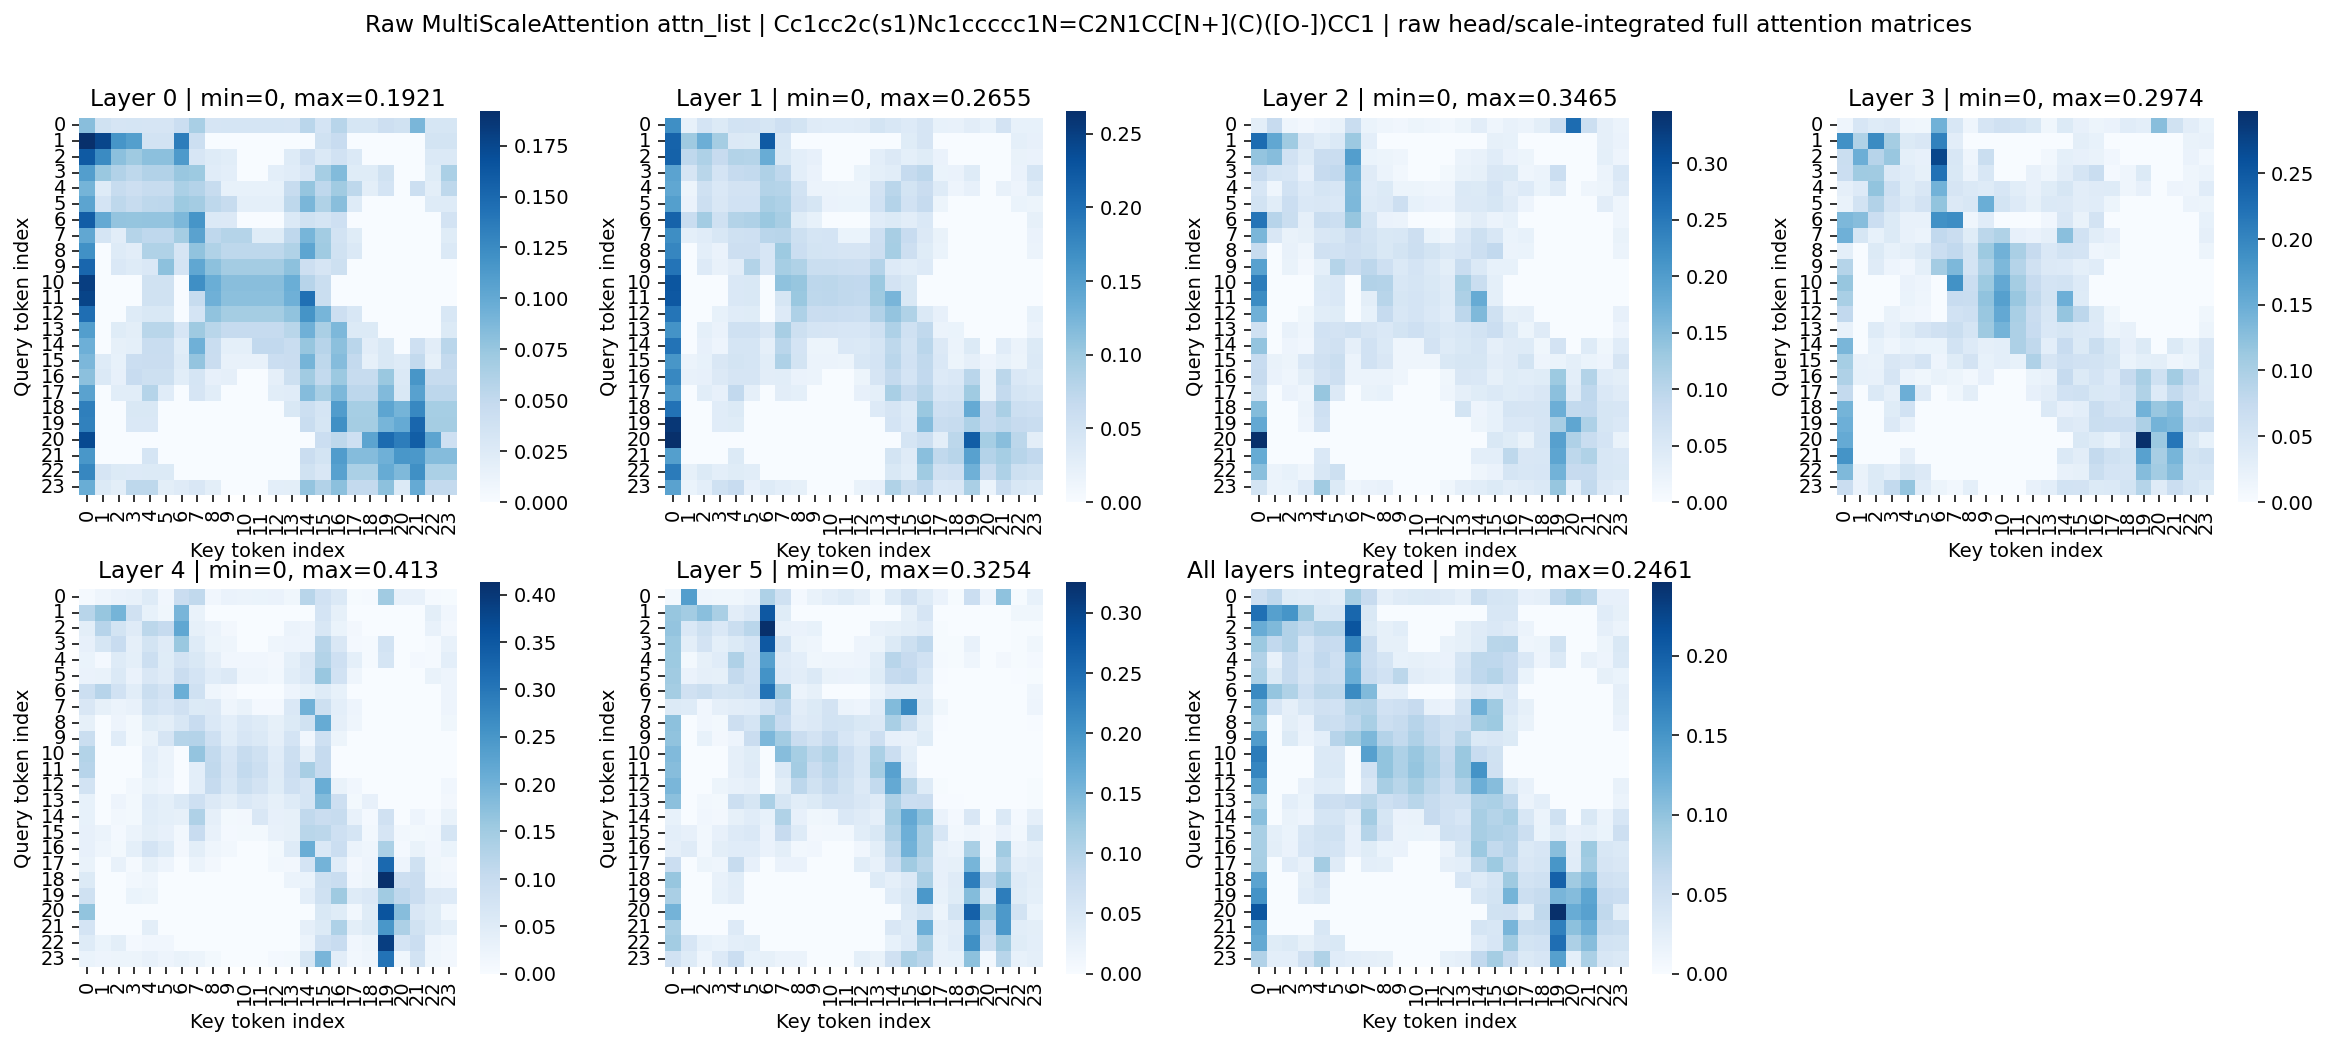

raw attn all layers integrated, shape=(24, 24), min=0, max=0.246103
Cliff device: cuda
Cliff smiles: Cc1cc2c(s1)Nc1ccccc1N=C2N1CC[N+](C)([O-])CC1
graph_feature (reg): -2.001652717590332
cliff_feature logit: 0.1643339842557907
cliff_feature prob : 0.5409913063049316
num_atoms: 23
aggregated atom_scores raw: [0.0665 0.0293 0.0277 0.0299 0.0258 0.0862 0.0611 0.0226 0.03   0.0334
 0.0343 0.0303 0.0228 0.056  0.0426 0.0408 0.0202 0.0222 0.0672 0.0835
 0.073  0.0209 0.0205]
aggregated atom_scores min-max: [0.7011 0.1369 0.1128 0.1461 0.0846 1.     0.6187 0.0361 0.1481 0.1985
 0.2134 0.1522 0.0393 0.5423 0.3388 0.312  0.     0.0289 0.7112 0.9584
 0.7992 0.0105 0.0039]
final-layer atom_scores raw (layer 5): [0.1866 0.0154 0.0136 0.013  0.0201 0.1063 0.0669 0.007  0.0233 0.0324
 0.0417 0.0298 0.0084 0.0416 0.0651 0.0416 0.0228 0.0029 0.0731 0.0173
 0.1337 0.003  0.0262]
final-layer atom_scores min-max (layer 5): [1.     0.0678 0.0584 0.055  0.0936 0.5628 0.3483 0.0222 0.111  0.1604
 0.2109 0.14

In [12]:
# ===== Cliff 參數 =====
CLIFF_SMILES = 'Cc1cc2c(s1)Nc1ccccc1N=C2N1CC[N+](C)([O-])CC1'
CLIFF_GPU_ID = '0'

# 請替換成你的 cliff 權重路徑
CLIFF_CKPT_PATH = './weights/cliff/CHEMBL231_Ki.pth'

# dist_bar 會從 checkpoint 還原，避免手動設定與模型訓練設定不一致。

CLIFF_SAVE_PREFIX = 'cliff_demo'
SAVE_DIR = Path('./result/attention_vis')
SAVE_DIR.mkdir(parents=True, exist_ok=True)


def build_cliff_runtime_config(ckpt_path: str):
    cfg_path = Path(pdir) / 'config' / 'config_finetune_cliff.yaml'
    with open(cfg_path, 'r', encoding='utf-8') as f:
        cfg = yaml.load(f, Loader=yaml.FullLoader)
    cfg = config_current_user('cliff', cfg)
    cfg = config_dataset_form('pkl', cfg)
    cfg['checkpoint'] = ckpt_path
    return cfg


def restore_dist_bar_from_ckpt(ckpt_obj):
    state = ckpt_obj.get('model', ckpt_obj)
    if not isinstance(state, dict) or 'dist_bar' not in state:
        raise RuntimeError('Checkpoint does not contain dist_bar; cannot guarantee matching multiscale attention settings.')

    dist_bar = state['dist_bar']
    if torch.is_tensor(dist_bar):
        dist_bar = dist_bar.detach().cpu().numpy().tolist()
    elif hasattr(dist_bar, 'tolist'):
        dist_bar = dist_bar.tolist()

    GlobalVar.dist_bar = list(dist_bar)
    return GlobalVar.dist_bar


def build_cliff_model(cfg: Dict, device: str = 'cuda') -> torch.nn.Module:
    model = Scage(
        mode=cfg['mode'],  # cliff
        atom_names=CompoundKit.atom_vocab_dict.keys(),
        atom_embed_dim=cfg['model']['atom_embed_dim'],
        num_kernel=cfg['model']['num_kernel'],
        layer_num=cfg['model']['layer_num'],
        num_heads=cfg['model']['num_heads'],
        atom_FG_class=nfg() + 1,
        hidden_size=cfg['model']['hidden_size'],
        num_tasks=1,
    ).to(device)

    ckpt = torch.load(cfg['checkpoint'], map_location=device)
    state = ckpt.get('model', ckpt)
    state = {k[7:] if k.startswith('module.') else k: v for k, v in state.items()}
    cur = model.state_dict()
    cur.update({k: v for k, v in state.items() if k in cur})
    model.load_state_dict(cur)
    model.eval()
    return model


os.environ['CUDA_VISIBLE_DEVICES'] = CLIFF_GPU_ID
CLIFF_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

cliff_cfg = build_cliff_runtime_config(CLIFF_CKPT_PATH)
cliff_ckpt = torch.load(cliff_cfg['checkpoint'], map_location=CLIFF_DEVICE)
restored_dist_bar = restore_dist_bar_from_ckpt(cliff_ckpt)
print('restored dist_bar from checkpoint:', restored_dist_bar)
cliff_model = build_cliff_model(cliff_cfg, device=CLIFF_DEVICE)
cliff_batch = build_single_batch(CLIFF_SMILES, device=CLIFF_DEVICE)

cliff_attn_sink = []
cliff_hooks = register_attention_hooks(cliff_model, cliff_attn_sink)
with torch.no_grad():
    cliff_out = cliff_model(cliff_batch)
for h in cliff_hooks:
    h.remove()

cliff_graph_score = float(cliff_out['graph_feature'].view(-1).cpu().numpy()[0])
cliff_cls_logit = float(cliff_out['cliff_feature'].view(-1).cpu().numpy()[0])
cliff_cls_prob = float(torch.sigmoid(torch.tensor(cliff_cls_logit)).item())

cliff_n_atoms = int(cliff_batch['atom_length'][0].item())
cliff_raw_attn_figs = plot_raw_multiscale_attn_list(
    cliff_attn_sink,
    title_prefix=f'Raw MultiScaleAttention attn_list | {CLIFF_SMILES}',
)
(
    cliff_atom_heatmap,
    cliff_atom_scores_raw,
    cliff_atom_scores,
    cliff_layer_heatmaps,
) = aggregate_attention(cliff_attn_sink, n_atoms=cliff_n_atoms)
cliff_final_layer_idx = len(cliff_layer_heatmaps) - 1
(
    cliff_final_heatmap,
    cliff_final_atom_scores_raw,
    cliff_final_atom_scores,
    _,
) = aggregate_attention(
    cliff_attn_sink,
    n_atoms=cliff_n_atoms,
    layer_idx=cliff_final_layer_idx,
)
cliff_bond_scores, cliff_bond_indices = compute_bond_scores(CLIFF_SMILES, cliff_atom_scores)
cliff_attention_result = {
    'per_layer_minmax': [h.reshape(-1) for h in cliff_layer_heatmaps],
    'aggregated_raw': cliff_atom_scores_raw,
    'aggregated_minmax': cliff_atom_scores,
    'final_layer_raw': cliff_final_atom_scores_raw,
    'final_layer_minmax': cliff_final_atom_scores,
    'bond_score_minmax': cliff_bond_scores,
    'bond_index': cliff_bond_indices,
    'smiles': CLIFF_SMILES,
    'image_paths': {},
}

print('Cliff device:', CLIFF_DEVICE)
print('Cliff smiles:', CLIFF_SMILES)
print('graph_feature (reg):', cliff_graph_score)
print('cliff_feature logit:', cliff_cls_logit)
print('cliff_feature prob :', cliff_cls_prob)
print('num_atoms:', cliff_n_atoms)
print('aggregated atom_scores raw:', np.round(cliff_atom_scores_raw, 6))
print('aggregated atom_scores min-max:', np.round(cliff_atom_scores, 4))
print(f'final-layer atom_scores raw (layer {cliff_final_layer_idx}):', np.round(cliff_final_atom_scores_raw, 6))
print(f'final-layer atom_scores min-max (layer {cliff_final_layer_idx}):', np.round(cliff_final_atom_scores, 4))

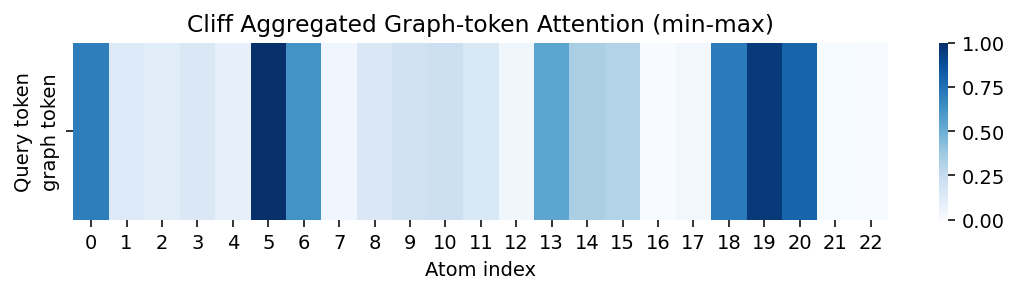

saved: result/attention_vis/cliff_demo_heatmap.png


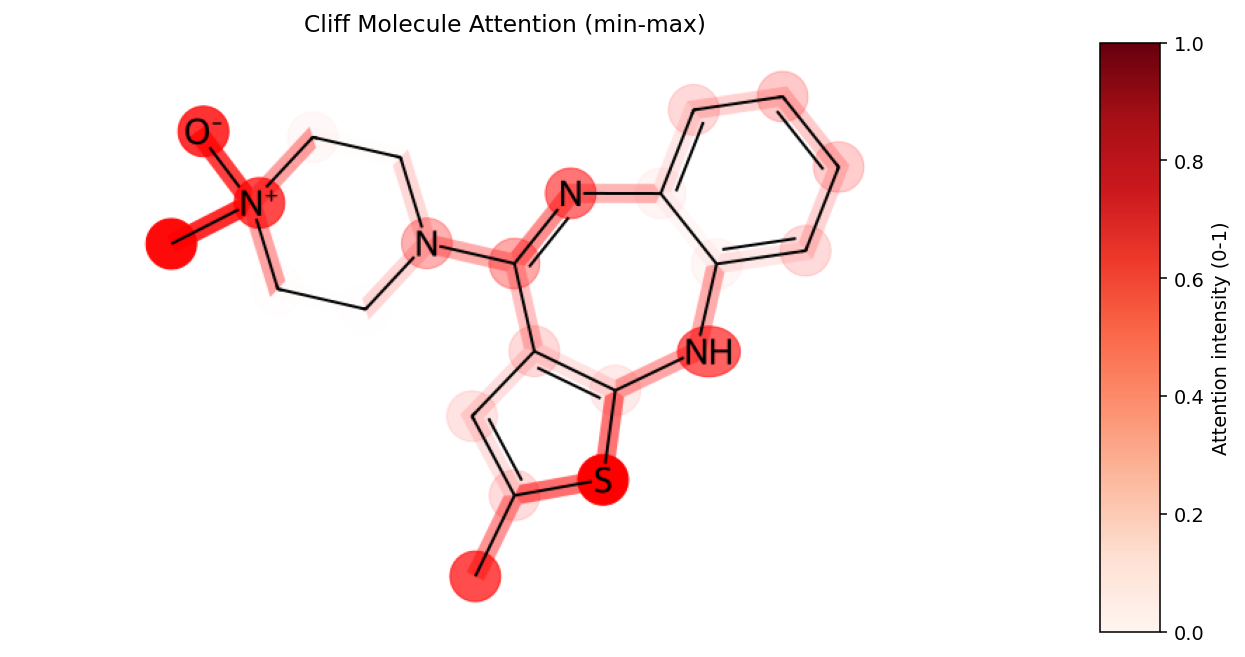

saved: result/attention_vis/cliff_demo_mol_attention.png

Atom score list (raw vs min-max):
atom  0: raw=0.066522 | min-max=0.7011
atom  1: raw=0.029285 | min-max=0.1369
atom  2: raw=0.027695 | min-max=0.1128
atom  3: raw=0.029893 | min-max=0.1461
atom  4: raw=0.025829 | min-max=0.0846
atom  5: raw=0.086249 | min-max=1.0000
atom  6: raw=0.061083 | min-max=0.6187
atom  7: raw=0.022627 | min-max=0.0361
atom  8: raw=0.030024 | min-max=0.1481
atom  9: raw=0.033352 | min-max=0.1985
atom 10: raw=0.034330 | min-max=0.2134
atom 11: raw=0.030294 | min-max=0.1522
atom 12: raw=0.022839 | min-max=0.0393
atom 13: raw=0.056041 | min-max=0.5423
atom 14: raw=0.042608 | min-max=0.3388
atom 15: raw=0.040841 | min-max=0.3120
atom 16: raw=0.020247 | min-max=0.0000
atom 17: raw=0.022154 | min-max=0.0289
atom 18: raw=0.067188 | min-max=0.7112
atom 19: raw=0.083504 | min-max=0.9584
atom 20: raw=0.072995 | min-max=0.7992
atom 21: raw=0.020941 | min-max=0.0105
atom 22: raw=0.020507 | min-max=0.0039


In [13]:
# Cliff: all-layer aggregated graph-token -> atom attention heatmap（min-max normalization）
plt.figure(figsize=(8.0, 2.2))
sns.heatmap(
    cliff_atom_heatmap,
    cmap='Blues',
    vmin=0.0,
    vmax=1.0,
    square=False,
    xticklabels=[str(i) for i in range(cliff_atom_heatmap.shape[1])],
    yticklabels=['graph token'],
)
plt.title('Cliff Aggregated Graph-token Attention (min-max)')
plt.xlabel('Atom index')
plt.ylabel('Query token')
plt.tight_layout()
cliff_heatmap_path = SAVE_DIR / f'{CLIFF_SAVE_PREFIX}_heatmap.png'
plt.savefig(cliff_heatmap_path, dpi=220)
cliff_attention_result['image_paths']['aggregated_heatmap'] = str(cliff_heatmap_path)
plt.show()
print('saved:', cliff_heatmap_path)
# Cliff: 結構圖 + 紅色 0-1 colorbar（min-max normalization）
cliff_img_bytes = draw_attention_on_molecule(CLIFF_SMILES, cliff_atom_scores)
cliff_png_path = SAVE_DIR / f'{CLIFF_SAVE_PREFIX}_mol_attention.png'
with open(cliff_png_path, 'wb') as f:
    f.write(cliff_img_bytes)
fig, axes = plt.subplots(1, 2, figsize=(9.8, 4.8), gridspec_kw={'width_ratios': [20, 1]})
axes[0].imshow(plt.imread(str(cliff_png_path)))
axes[0].axis('off')
axes[0].set_title('Cliff Molecule Attention (min-max)')
norm = plt.Normalize(0.0, 1.0)
sm = plt.cm.ScalarMappable(cmap='Reds', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=axes[1])
cbar.set_label('Attention intensity (0-1)')
plt.tight_layout()
cliff_attention_result['image_paths']['aggregated_mol'] = str(cliff_png_path)
plt.show()
print('saved:', cliff_png_path)
print('\nAtom score list (raw vs min-max):')
for i, (s_raw, s_minmax) in enumerate(zip(cliff_atom_scores_raw, cliff_atom_scores)):
    print(f'atom {i:>2d}: raw={s_raw:.6f} | min-max={s_minmax:.4f}')



Render per-layer heatmaps and molecule attention plots (no file export) ...


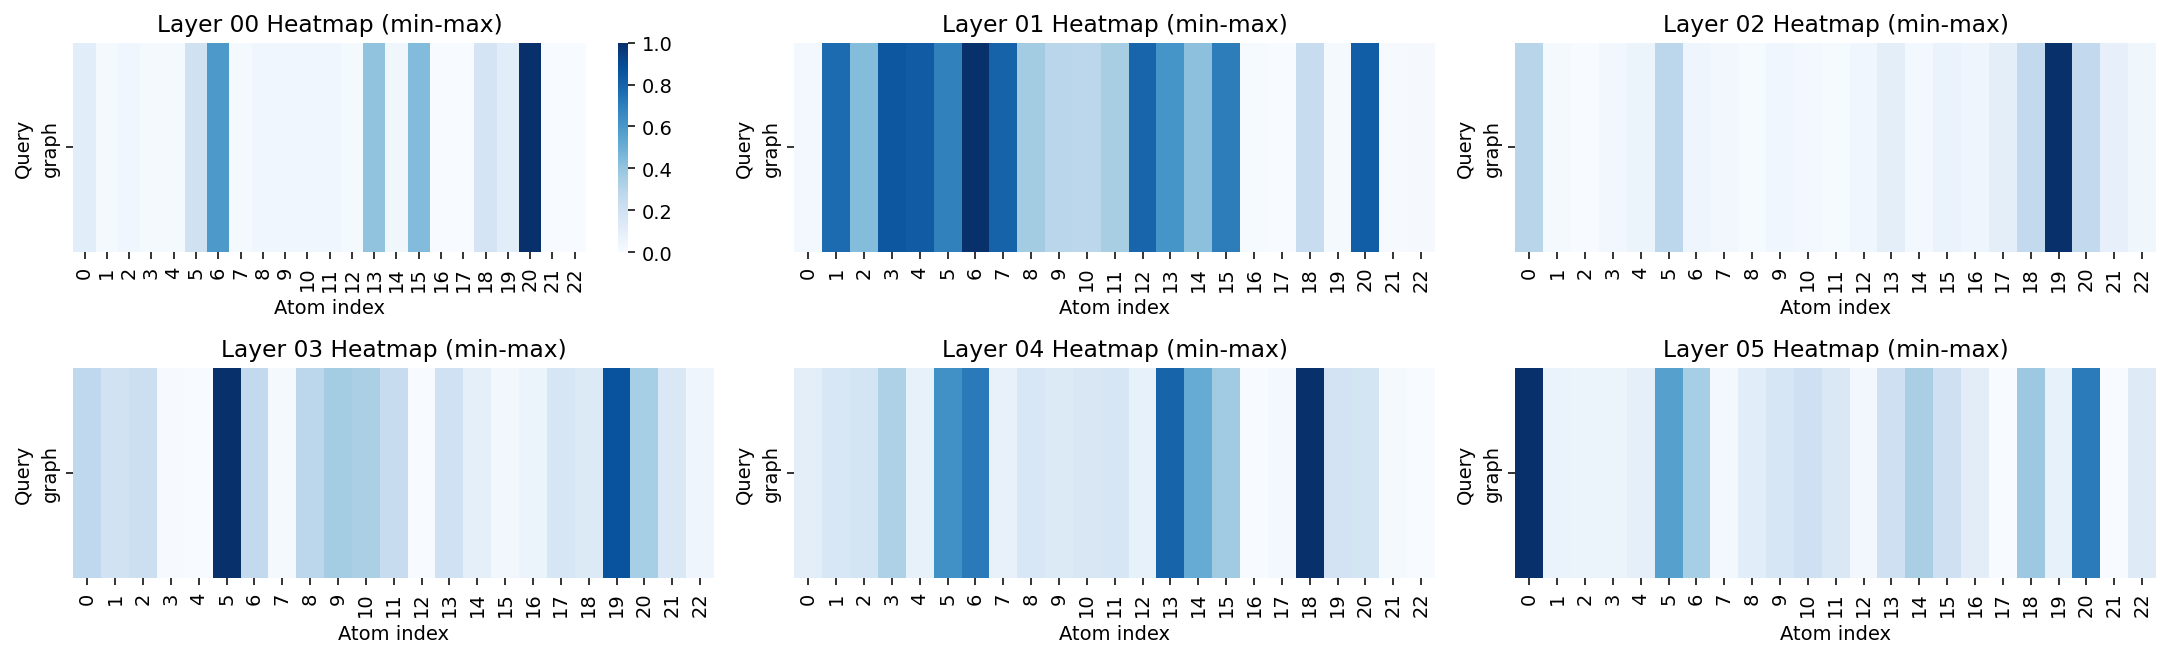

layer 00 rendered (in-memory)
layer 01 rendered (in-memory)
layer 02 rendered (in-memory)
layer 03 rendered (in-memory)
layer 04 rendered (in-memory)
layer 05 rendered (in-memory)
Total rendered: 6 layer plots


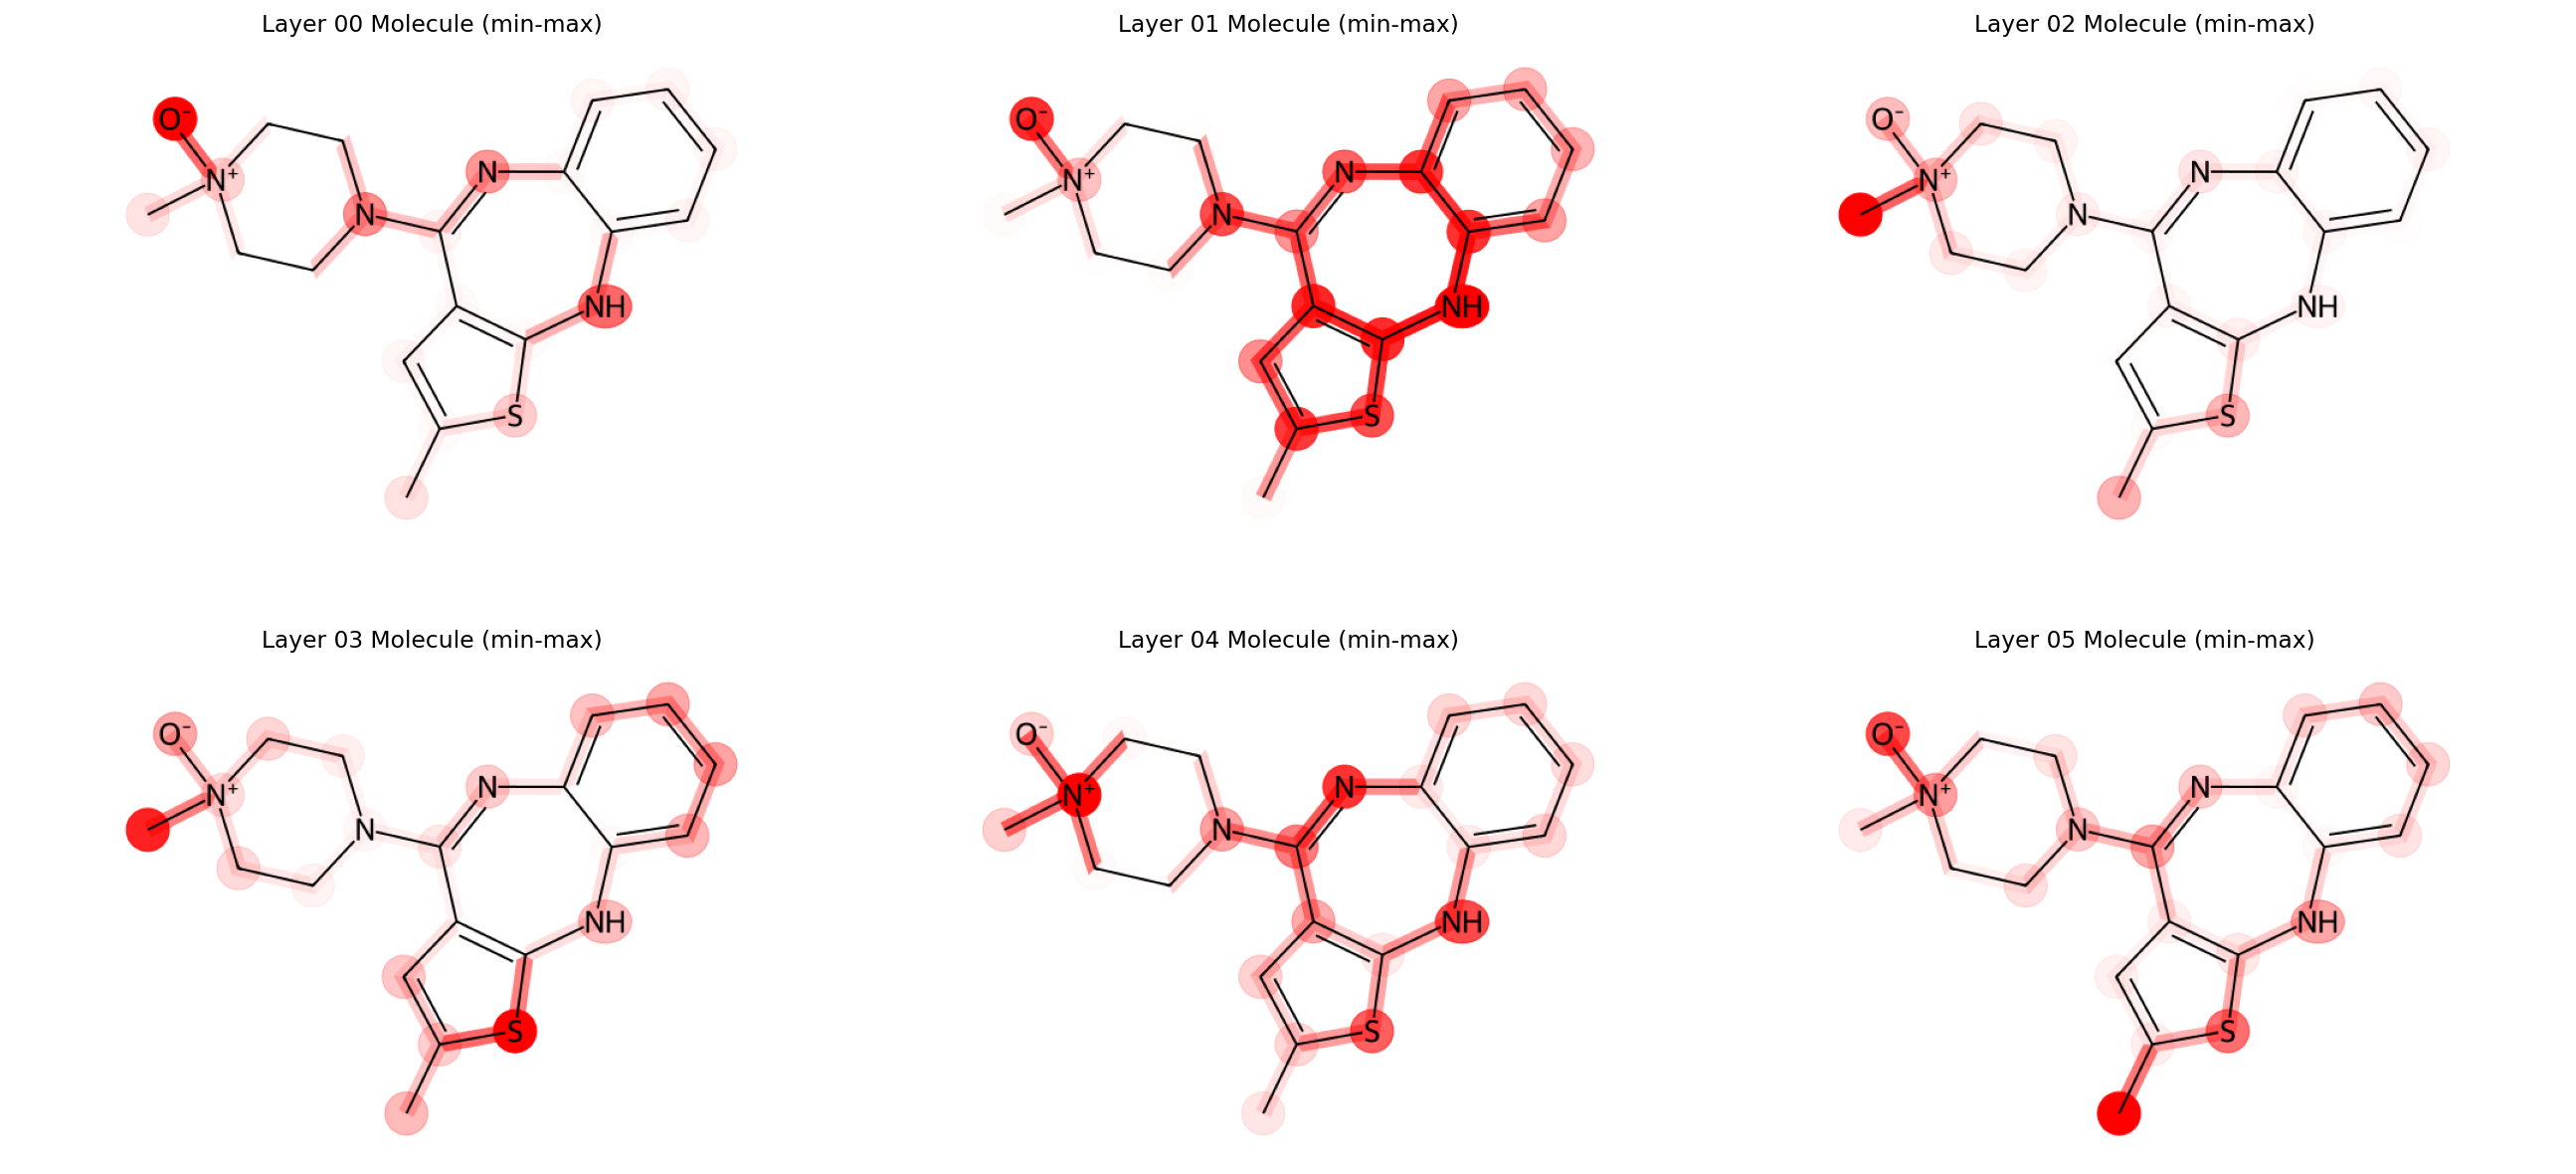

In [14]:
# 自動迴圈：逐層生成 attention 圖（heatmap + 分子結構，僅顯示，不寫檔）
print('\nRender per-layer heatmaps and molecule attention plots (no file export) ...')
from io import BytesIO

n_layers = len(cliff_layer_heatmaps)

# A) 每層 heatmap
heat_cols = min(3, n_layers)
heat_rows = int(np.ceil(n_layers / heat_cols))
fig, axes = plt.subplots(heat_rows, heat_cols, figsize=(5.2 * heat_cols, 2.4 * heat_rows))
axes = np.array(axes).reshape(-1)
for i in range(n_layers):
    sns.heatmap(
        cliff_layer_heatmaps[i],
        cmap='Blues',
        vmin=0.0,
        vmax=1.0,
        square=False,
        xticklabels=[str(j) for j in range(cliff_layer_heatmaps[i].shape[1])],
        yticklabels=['graph'],
        cbar=(i == 0),
        ax=axes[i],
    )
    axes[i].set_title(f'Layer {i:02d} Heatmap (min-max)')
    axes[i].set_xlabel('Atom index')
    axes[i].set_ylabel('Query')
for j in range(n_layers, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

# B) 每層分子結構 attention 圖（in-memory）
per_layer_imgs = []
for i, layer_heatmap in enumerate(cliff_layer_heatmaps):
    layer_scores = layer_heatmap.reshape(-1)
    layer_img_bytes = draw_attention_on_molecule(CLIFF_SMILES, layer_scores)
    per_layer_imgs.append(layer_img_bytes)
    print(f'layer {i:02d} rendered (in-memory)')
print(f'Total rendered: {len(per_layer_imgs)} layer plots')

show_cols = min(3, len(per_layer_imgs))
show_rows = int(np.ceil(len(per_layer_imgs) / show_cols))
fig, axes = plt.subplots(show_rows, show_cols, figsize=(6.2 * show_cols, 4.8 * show_rows))
axes = np.array(axes).reshape(-1)
for i, img_bytes in enumerate(per_layer_imgs):
    axes[i].imshow(plt.imread(BytesIO(img_bytes)))
    axes[i].axis('off')
    axes[i].set_title(f'Layer {i:02d} Molecule (min-max)')
for j in range(len(per_layer_imgs), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()
